### 당뇨 데이터 딥러닝으로 분류
202435119 한여원

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

In [19]:
df = pd.read_csv("D:\hanyeowon\Coding\pythonworks\deep\data\diabetes.csv")

y = df["Outcome"]
X = df.drop("Outcome", axis=1)
X = X.values
y = pd.get_dummies(y).values
print(X)
print(y)

[[  6.    148.     72.    ...  33.6     0.627  50.   ]
 [  1.     85.     66.    ...  26.6     0.351  31.   ]
 [  8.    183.     64.    ...  23.3     0.672  32.   ]
 ...
 [  5.    121.     72.    ...  26.2     0.245  30.   ]
 [  1.    126.     60.    ...  30.1     0.349  47.   ]
 [  1.     93.     70.    ...  30.4     0.315  23.   ]]
[[False  True]
 [ True False]
 [False  True]
 ...
 [ True False]
 [False  True]
 [ True False]]


<>:1: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\h'
C:\Users\gram\AppData\Local\Temp\ipykernel_23092\3462691607.py:1: SyntaxWarning: invalid escape sequence '\h'
  df = pd.read_csv("D:\hanyeowon\Coding\pythonworks\deep\data\diabetes.csv")


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6196 - loss: 0.6932 - val_accuracy: 0.7414 - val_loss: 0.6492
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6891 - loss: 0.6452 - val_accuracy: 0.7500 - val_loss: 0.6000
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7000 - loss: 0.6075 - val_accuracy: 0.7586 - val_loss: 0.5469
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7130 - loss: 0.5791 - val_accuracy: 0.7845 - val_loss: 0.5055
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7370 - loss: 0.5478 - val_accuracy: 0.7759 - val_loss: 0.4813
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7500 - loss: 0.5267 - val_accuracy: 0.7845 - val_loss: 0.4641
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7543 - loss: 0.5017 - val_accuracy: 0.8017 - val_loss: 0.4532
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7413 - loss: 0.4924 - val_accuracy: 0.7931 - val_loss

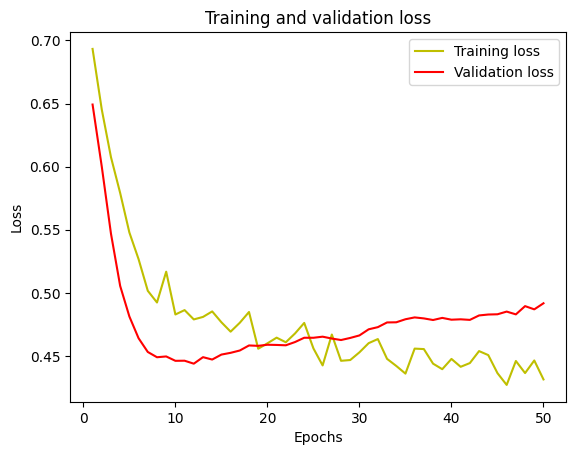

In [22]:
model = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X.shape[1], )),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(y.shape[1], activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test_scaled)

y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
import matplotlib.pyplot as plt

epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [23]:
print(loss)
print(val_loss)
print(acc)

[0.6932480931282043, 0.645238995552063, 0.6074761152267456, 0.5790761113166809, 0.5478264689445496, 0.5267014503479004, 0.5016669631004333, 0.4923960268497467, 0.5168042182922363, 0.4828958511352539, 0.4863739609718323, 0.4789895713329315, 0.48097169399261475, 0.48533040285110474, 0.47674131393432617, 0.4692971706390381, 0.47636306285858154, 0.4848741292953491, 0.45576879382133484, 0.46005818247795105, 0.46455085277557373, 0.4609057605266571, 0.46787554025650024, 0.4762139618396759, 0.45603278279304504, 0.44255682826042175, 0.46702250838279724, 0.44621893763542175, 0.44681841135025024, 0.45293253660202026, 0.4601803123950958, 0.46343812346458435, 0.44776099920272827, 0.44215238094329834, 0.4360710680484772, 0.45587244629859924, 0.45549753308296204, 0.44395381212234497, 0.43957170844078064, 0.44769394397735596, 0.44146430492401123, 0.4444192051887512, 0.45389971137046814, 0.450732946395874, 0.4364418089389801, 0.4271090626716614, 0.4460707902908325, 0.4364927411079407, 0.446479588747024

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))
# 정확도는 0.8 수준으로 준수해보이지만 잘 살펴보면 1(당뇨)를 개떡같이 못 맞추는 경향이 있다

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       130
           1       0.69      0.68      0.68        62

    accuracy                           0.80       192
   macro avg       0.77      0.77      0.77       192
weighted avg       0.80      0.80      0.80       192

[[111  19]
 [ 20  42]]
